# STAMP — Quick Start

This notebook walks through the core STAMP workflow:

1. Load 2-D grain diameter measurements from a plain-text file
2. Compute descriptive statistics with confidence intervals
3. Fit a parametric distribution by MLE
4. Apply the Saltykov / Wicksell stereological correction (2-D → 3-D)
5. Fit a lognormal distribution using the two-step method
6. Generate publication-ready figures

**Dataset**: `data/apparent_diameters.txt` — 500 apparent 2-D circle diameters (µm)
generated by Monte Carlo Wicksell sectioning of a synthetic lognormal 3-D grain
population (μ = 45 µm, σ = 0.35).  See `02_simulation_validation.ipynb` for how
this file was produced.

> **Using your own data**: replace the file path in §1 with your CSV / Excel / TXT
> file.  If your measurements are 2-D projected *areas* rather than diameters, convert
> them first with `stamp.stereo.ecd_from_area()` (see the note in §3).

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from stamp.io import load
from stamp.plot import distribution, qq_plot, saltykov_plot, twostep_plot
from stamp.stats import describe, fit
from stamp.stereo import saltykov, two_step

## 1. Load measurements

`stamp.io.load` reads a named column from CSV, Excel, or delimited text files
into a single-column `pd.DataFrame`.  Non-finite and non-positive values are
automatically dropped with a warning.  Physical unit and display label are
stored in `df.attrs["unit"]` and `df.attrs["label"]`, and the DataFrame can be
passed directly to all downstream `stamp` functions.

In [2]:
# Resolve path whether notebook is run from repo root or notebooks/
data_path = Path("notebooks/data/apparent_diameters.txt")
if not data_path.exists():
    data_path = Path("data/apparent_diameters.txt")

ecds = load(data_path, column="ECD_um", unit="µm", label="Grain ECD")

print(f"Loaded  : {len(ecds)} measurements")
print(f"Unit    : {ecds.attrs['unit']}")
print(f"Label   : {ecds.attrs['label']}")
print(f"Range   : {ecds.iloc[:, 0].min():.2f} – {ecds.iloc[:, 0].max():.2f} µm")

Loaded  : 500 measurements
Unit    : µm
Label   : Grain ECD
Range   : 0.95 – 179.19 µm


## 2. Quick look at the raw data

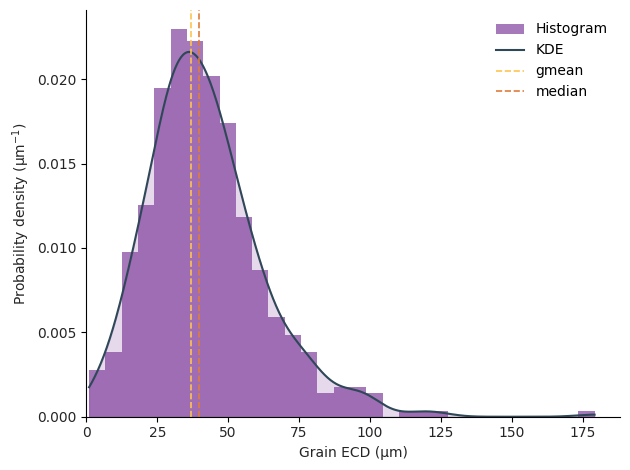

In [3]:
fig = distribution(ecds, avg=("gmean", "median"))
plt.show()

## 3. Working with area measurements

If your data file contains 2-D **projected areas** (e.g. from EBSD or image analysis
software), convert to equivalent circle diameters before proceeding:

```python
from stamp.stereo import ecd_from_area

areas = load("grains.csv", column="Area (µm²)", unit="µm²", label="Grain Area")
ecds  = ecd_from_area(areas)   # ECD = 2 √(A / π);  unit updated µm² → µm
```

The dataset used here was exported directly as diameters, so no conversion is needed.

## 4. Descriptive statistics with confidence intervals

`describe` returns arithmetic mean (ASTM CI), geometric mean (CLT CI), median
(Hollander–Wolfe CI), and KDE mode in a single call.

In [4]:
stats_result = describe(ecds)

am = stats_result.amean
gm = stats_result.gmean
md = stats_result.median
pk = stats_result.peak

print(f"n = {stats_result.n} measurements\n")
print(f"{'Statistic':<20} {'Value (µm)':>12}  {'95 % CI / IQR'}")
print("-" * 60)
print(f"{'Arithmetic mean':<20} {am.mean:>12.2f}  [{am.ci_low:.2f}, {am.ci_high:.2f}]")
print(f"{'Geometric mean':<20} {gm.mean:>12.2f}  [{gm.ci_low:.2f}, {gm.ci_high:.2f}]")
print(f"{'Median':<20} {md.median:>12.2f}  IQR {md.iqr:.2f} µm")
print(f"{'KDE mode':<20} {pk.peak:>12.2f}")

print("\nPercentiles (µm):")
for p, v in stats_result.percentiles.items():
    print(f"  P{p:>2} : {v:.2f}")

n = 500 measurements

Statistic              Value (µm)  95 % CI / IQR
------------------------------------------------------------
Arithmetic mean             42.21  [40.37, 44.04]
Geometric mean              36.80  [34.97, 38.73]
Median                      39.75  IQR 23.53 µm
KDE mode                    36.18

Percentiles (µm):
  P 5 : 13.95
  P10 : 18.97
  P25 : 28.73
  P75 : 52.26
  P90 : 67.87
  P95 : 78.81


## 5. Distribution fitting (MLE)

Fit a lognormal distribution by maximum likelihood and check the KS goodness-of-fit.
The fitted PDF is overlaid on the histogram.

Distribution  : lognormal
MLE params    : {'s': 0.580576262018155, 'loc': 0.0, 'scale': 36.802962188543376}
R²            : 0.9729
KS statistic  : 0.0888
KS p-value    : 0.0007  (rejected at α=0.05)


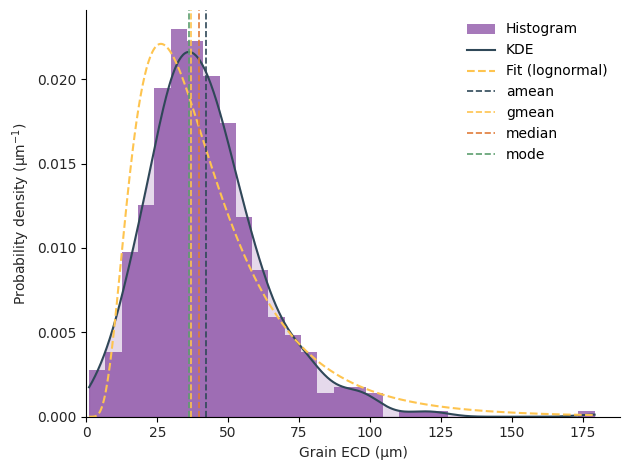

In [5]:
fit_result = fit(ecds, distribution="lognormal")

print(f"Distribution  : {fit_result.distribution}")
print(f"MLE params    : {fit_result.params}")
print(f"R²            : {fit_result.r_squared:.4f}")
print(f"KS statistic  : {fit_result.ks_statistic:.4f}")
print(f"KS p-value    : {fit_result.ks_pvalue:.4f}  "
      f"({'not rejected' if fit_result.ks_pvalue > 0.05 else 'rejected'} at α=0.05)")

fig = distribution(ecds, fit=fit_result)
plt.show()

## 6. Saltykov / Wicksell stereological correction

The 2-D apparent diameters are systematically smaller than the true 3-D grain sizes —
the **Wicksell corpuscle bias**.  The Saltykov method unfolds the 2-D distribution into
a 3-D sphere-diameter distribution using Wicksell's (1925) cross-section probability matrix.

Bins      : 12
Bin width : 14.93 µm
Range     : 0.00 – 179.19 µm

Saltykov geometric mean  : 43.67 µm  (corrected)
2-D apparent geom. mean  : 36.80 µm  (uncorrected)


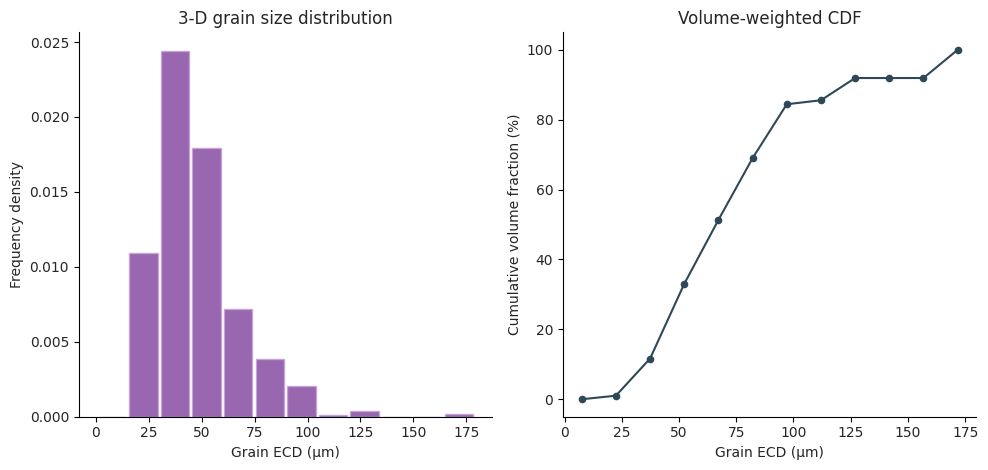

In [6]:
sal = saltykov(ecds, n_bins=12)

# Volume-weighted geometric mean from the Saltykov distribution
w = sal.freq3d * sal.bin_width
gmean_sal = np.exp(np.dot(w, np.log(sal.bin_midpoints)) / w.sum())

print(f"Bins      : {sal.bin_midpoints.size}")
print(f"Bin width : {sal.bin_width:.2f} µm")
print(f"Range     : {sal.bin_edges[0]:.2f} – {sal.bin_edges[-1]:.2f} µm")
print(f"\nSaltykov geometric mean  : {gmean_sal:.2f} µm  (corrected)")
print(f"2-D apparent geom. mean  : {stats_result.gmean.mean:.2f} µm  (uncorrected)")

fig = saltykov_plot(sal)
plt.show()

## 7. Two-step lognormal fit

Iterates Saltykov over a range of bin counts, fits a lognormal PDF to each result,
and selects the bin count minimising the residual sum of squares
(Lopez-Sanchez & Llana-Funez 2016).  Returns the best-fit geometric mean and
log-shape σ with a ±3σ uncertainty band.

Best bin count  : 11
Geometric mean  : 43.84 µm
Log-shape σ     : 0.388  (multiplicative σ = 1.474)


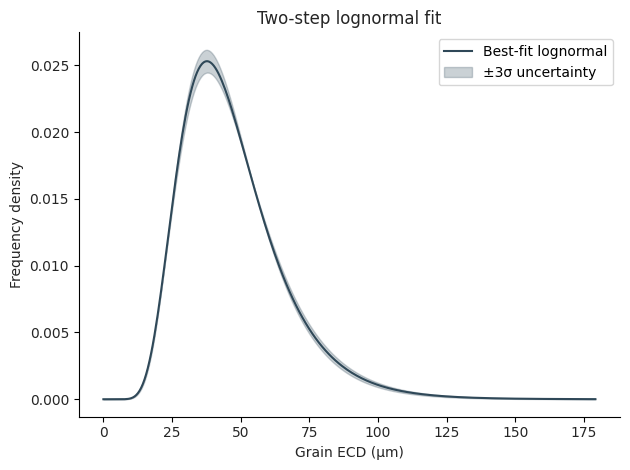

In [7]:
ts = two_step(ecds, bin_range=(10, 20))

print(f"Best bin count  : {ts.best_n_bins}")
print(f"Geometric mean  : {ts.geometric_mean:.2f} µm")
print(f"Log-shape σ     : {np.log(ts.shape):.3f}  "
      f"(multiplicative σ = {ts.shape:.3f})")

fig = twostep_plot(ts)
plt.show()

## 8. Q-Q plot

Check whether the 2-D ECD distribution is consistent with a lognormal model.

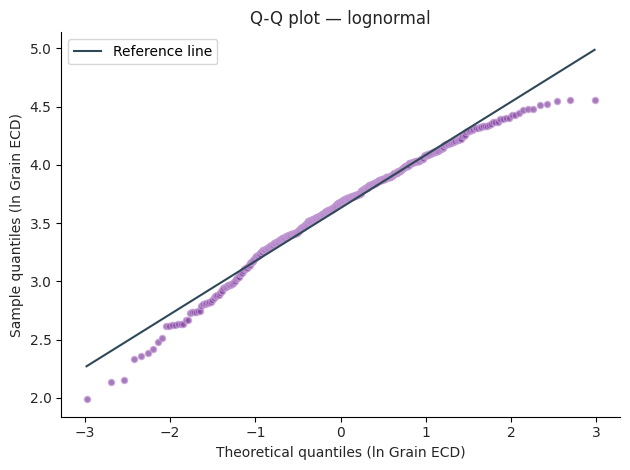

In [8]:
fig = qq_plot(ecds, distribution="lognormal")
plt.show()

## Summary

| Quantity | 2-D apparent (uncorrected) | 3-D estimate (two-step) |
|----------|---------------------------|-------------------------|
| Geometric mean (µm) | `stats_result.gmean.mean` | `ts.geometric_mean` |
| Log-shape σ | — | `np.log(ts.shape)` |

The two-step correction recovers the true 3-D geometric mean, correcting for the
systematic Wicksell bias present in 2-D sections.

For a rigorous validation of the correction accuracy against the known ground truth
of the dataset loaded here, see **02_simulation_validation.ipynb**.

## 9. Publication-ready export

`stamp.export` applies journal typographic conventions to any STAMP figure and exports
results tables as CSV or LaTeX (booktabs style).  Three steps are demonstrated below:

- **Default style** — consensus journal conventions (Arial 8 pt, 89 mm single column, 600 dpi)
- **Nature preset** — Nature Publishing Group specifications (Arial 7 pt, B&W)
- **Granular override** — one field changed on top of a preset
- **Table export** — descriptive statistics from §4 exported as CSV and LaTeX

In [9]:
import pandas as pd
from stamp.export import JournalStyle, journal_style, figure_for, save, to_csv, to_latex

# ── Style objects ──────────────────────────────────────────────────────────────
default_style = JournalStyle()                       # "default" preset
nature_style  = JournalStyle(preset="nature")        # Nature Publishing Group spec
custom_style  = JournalStyle(preset="nature", font_size=9)  # granular override

print(f"Default  → font: {default_style.font_family}, size: {default_style.font_size} pt, "
      f"col width: {default_style.single_col_mm} mm")
print(f"Nature   → font: {nature_style.font_family}, size: {nature_style.font_size} pt, "
      f"col width: {nature_style.single_col_mm} mm")
print(f"Custom   → font: {custom_style.font_family}, size: {custom_style.font_size} pt "
      f"(overridden), tick: {custom_style.tick_size} pt (from nature preset)")

Default  → font: Arial, size: 8.0 pt, col width: 89.0 mm
Nature   → font: Arial, size: 7.0 pt, col width: 89.0 mm
Custom   → font: Arial, size: 9 pt (overridden), tick: 6.0 pt (from nature preset)


Saved: notebooks\data\fig_default.png


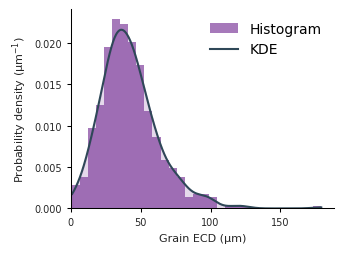

Saved: notebooks\data\fig_nature.png


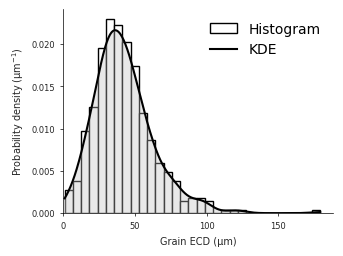

Saved: notebooks\data\fig_custom.png


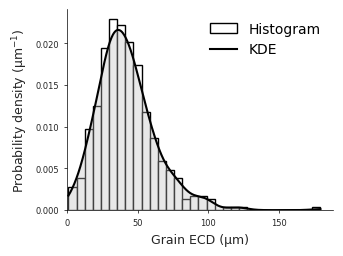

In [10]:
# ── Compare default vs Nature preset vs custom override ───────────────────────
# Each style renders in its own figure at the correct print column width.
# The nature and custom styles use B&W colours automatically.
# Figures are saved as PNG at 600 dpi (journal-submission quality).

out_dir = Path("notebooks/data")
if not out_dir.exists():
    out_dir = Path("data")

fig_names = ["fig_default", "fig_nature", "fig_custom"]
for style, name in zip([default_style, nature_style, custom_style], fig_names):
    with journal_style(style):
        w_in = style.single_col_mm / 25.4
        fig = distribution(ecds, figsize=(w_in, w_in * 0.75), avg=())
        paths = save(fig, out_dir / name, formats=["png"])
    print(f"Saved: {paths[0]}")
    plt.show()

In [11]:
from IPython.display import display, Latex

# ── Table export — descriptive statistics from §4 ─────────────────────────────
summary_df = pd.DataFrame({
    "Statistic":    ["Arithmetic mean", "Geometric mean", "Median", "KDE mode"],
    "Value":        [stats_result.amean.mean, stats_result.gmean.mean,
                     stats_result.median.median, stats_result.peak.peak],
    "95 % CI low":  [stats_result.amean.ci_low, stats_result.gmean.ci_low,
                     stats_result.median.ci_low, float("nan")],
    "95 % CI high": [stats_result.amean.ci_high, stats_result.gmean.ci_high,
                     stats_result.median.ci_high, float("nan")],
})

# HTML preview in the notebook
num_cols = ["Value", "95 % CI low", "95 % CI high"]
display(
    summary_df.style
    .format("{:.2f}", subset=num_cols, na_rep="—")
    .set_caption("Descriptive statistics of 2-D grain ECD measurements (n = 500).")
)

# Same path-resolution pattern used throughout this notebook
out_dir = Path("notebooks/data")
if not out_dir.exists():
    out_dir = Path("data")

# CSV
to_csv(summary_df, out_dir / "table1_stats.csv", decimals=2)
print("CSV written to", out_dir / "table1_stats.csv")

# LaTeX — full source (with \begin{table} wrapper) for writing to disk.
# row_notes places \tnote{} markers in the label column so each footnote
# key has a clear referent in the table body.
# Use ASCII -- for en-dash in footnote strings (LaTeX convention).
latex_str = to_latex(
    summary_df,
    caption="Descriptive statistics of 2-D grain ECD measurements (n = 500).",
    label="tab:stats",
    units={"Value": "µm", "95 % CI low": "µm", "95 % CI high": "µm"},
    decimals=2,
    row_notes={"Geometric mean": "a", "Median": "b"},
    footnotes={
        "a": "CLT confidence interval.",
        "b": "Hollander--Wolfe confidence interval.",
    },
)

# MathJax can't render \begin{table} float environments, so strip the wrapper
# before inline display and show just the \begin{tabular}...\end{tabular} block
_float_cmds = (r"\begin{table}", r"\end{table}", r"\caption", r"\label")
tabular_src = "\n".join(
    line for line in latex_str.splitlines()
    if not any(line.startswith(cmd) for cmd in _float_cmds)
)
display(Latex(tabular_src))

print(latex_str)

,Statistic,Value,95 % CI low,95 % CI high
0,Arithmetic mean,42.21,40.37,44.04
1,Geometric mean,36.80,34.97,38.73
2,Median,39.75,37.19,41.46
3,KDE mode,36.18,—,—


CSV written to notebooks\data\table1_stats.csv


<IPython.core.display.Latex object>

\begin{table}
\centering
\caption{Descriptive statistics of 2-D grain ECD measurements (n = 500).}
\label{tab:stats}
\begin{threeparttable}
\begin{tabular}{lrrr}
\toprule
Statistic & Value (\textmu{}m) & 95\,\% CI low (\textmu{}m) & 95\,\% CI high (\textmu{}m) \\
\midrule
Arithmetic mean & 42.21 & 40.37 & 44.04 \\
Geometric mean\tnote{a} & 36.80 & 34.97 & 38.73 \\
Median\tnote{b} & 39.75 & 37.19 & 41.46 \\
KDE mode & 36.18 & --- & --- \\
\bottomrule
\end{tabular}
\begin{tablenotes}[flushleft]
\footnotesize
\item[a] CLT confidence interval.
\item[b] Hollander--Wolfe confidence interval.
\end{tablenotes}
\end{threeparttable}
\end{table}

